Epoch    0 | Total Loss = 24337.501953 | Data Loss = 256.843994 | Physics Loss = 481613.156250
Epoch   10 | Total Loss = 12964.260742 | Data Loss = 136.804886 | Physics Loss = 256549.109375
Epoch   20 | Total Loss = 4685.379395 | Data Loss = 49.424313 | Physics Loss = 92719.101562
Epoch   30 | Total Loss = 715.921631 | Data Loss = 7.526671 | Physics Loss = 14167.898438
Epoch   40 | Total Loss = 447.854370 | Data Loss = 4.700089 | Physics Loss = 8863.084961
Epoch   50 | Total Loss = 221.978821 | Data Loss = 2.324941 | Physics Loss = 4393.077637
Epoch   60 | Total Loss = 115.676994 | Data Loss = 1.209594 | Physics Loss = 2289.347900
Epoch   70 | Total Loss = 64.393944 | Data Loss = 0.667316 | Physics Loss = 1274.532593
Epoch   80 | Total Loss = 36.235474 | Data Loss = 0.368978 | Physics Loss = 717.329956
Epoch   90 | Total Loss = 22.451883 | Data Loss = 0.225775 | Physics Loss = 444.522156
Epoch  100 | Total Loss = 15.059912 | Data Loss = 0.150068 | Physics Loss = 298.196869
Epoch  110 |

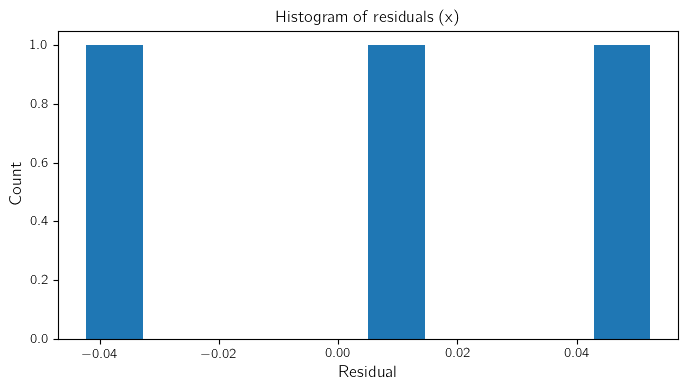

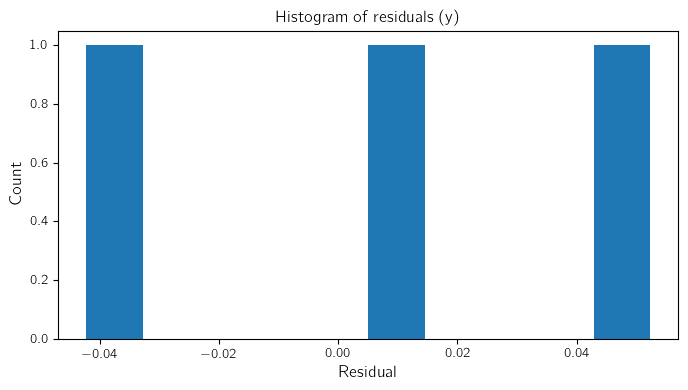

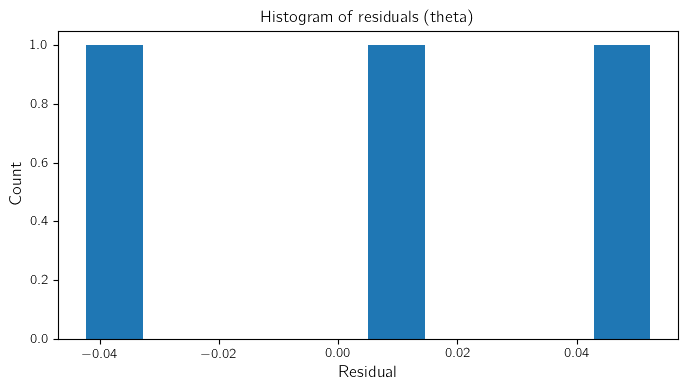

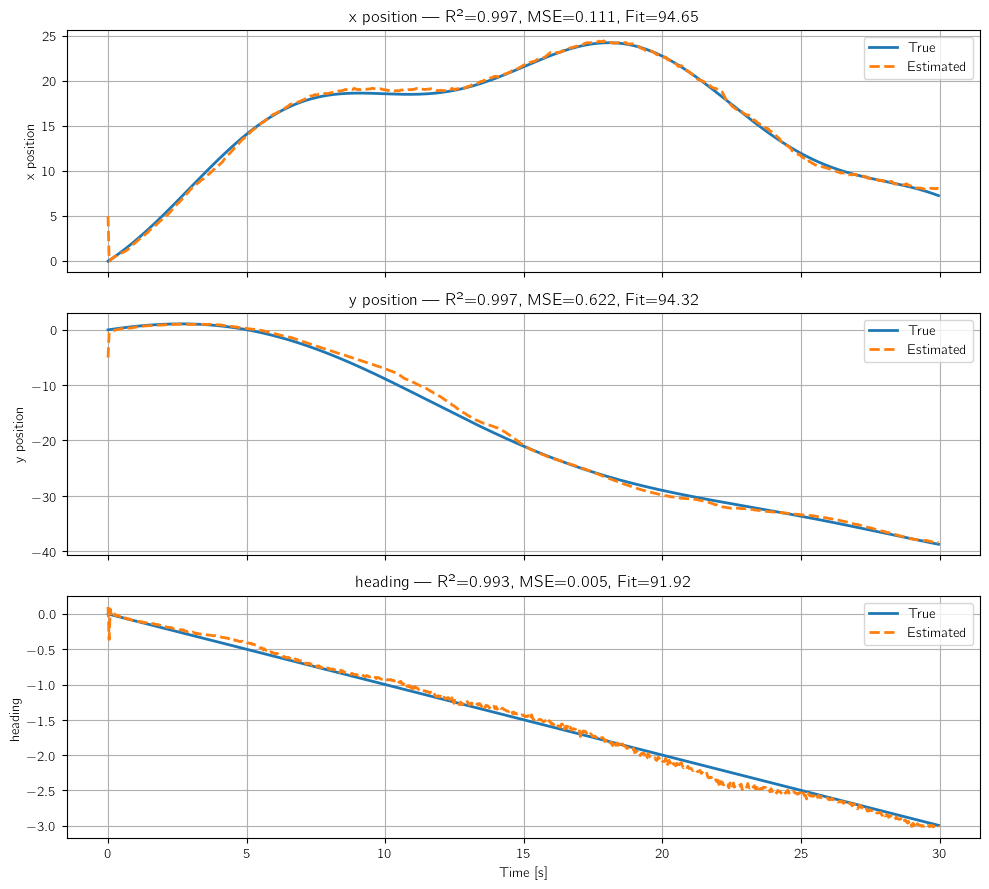

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


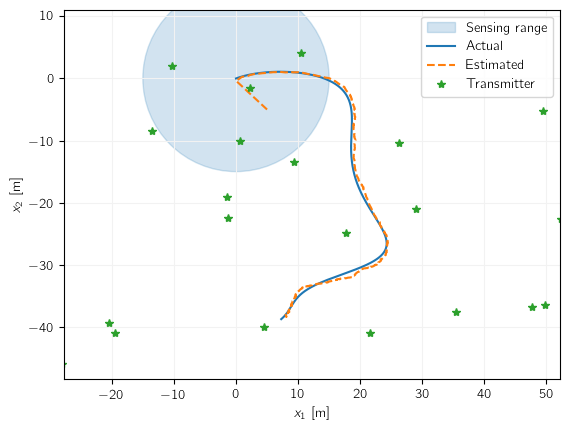

In [3]:
#PINN Incorperated with UKF + Model Analysis
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split

from integration2 import rk_four
from models2 import DiffDrive

from matplotlib.patches import Circle
from scipy.stats import chi2
from scipy.linalg import block_diag
from numpy.linalg import inv

np.random.seed(42)
tf.random.set_seed(42)

# ============================================================
# Monte Carlo Dropout (always active at inference too)
# ============================================================
class MonteCarloDropout(tf.keras.layers.Dropout): #Can be included at inference and training, generating 10 forward passes and grabbing the mean prediction and std. Decided to not include due to runtime
    def call(self, inputs, training=None):
        return super().call(inputs, training=True)


# ============================================================
# PINN model
# Input  : [x, y, theta, v_L, v_R]   shape (batch, 5)
# Output : [x_next, y_next, theta_next] shape (batch, 3)
# ============================================================
def create_pinn(input_dim=5, output_dim=3):
    return tf.keras.Sequential([
        tf.keras.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=l2(0.001)),
        tf.keras.layers.Dense(output_dim)
    ])

# ============================================================
# Losses
# ============================================================
def data_loss_fn(pred, y_true):
    return tf.reduce_mean(tf.square(pred - y_true))


def physics_loss(x_next_pred, x_batch, u_batch, dt, ell):
    """
    x_batch: (batch, 3) = [x, y, theta]
    u_batch: (batch, 2) = [v_L, v_R]
    x_next_pred: (batch, 3) = predicted next state
    """
    x_curr = x_batch[:, 0:1]
    y_curr = x_batch[:, 1:2]
    theta_curr = x_batch[:, 2:3]

    v_L = u_batch[:, 0:1]
    v_R = u_batch[:, 1:2]

    x_next = x_next_pred[:, 0:1]
    y_next = x_next_pred[:, 1:2]
    theta_next = x_next_pred[:, 2:3]

    # finite-difference derivative implied by predicted next state
    x_dot_pred = (x_next - x_curr) / dt
    y_dot_pred = (y_next - y_curr) / dt
    theta_dot_pred = (theta_next - theta_curr) / dt

    # nominal diff-drive kinematics
    v = 0.5 * (v_L + v_R)
    x_dot_phys = v * tf.cos(theta_curr)
    y_dot_phys = v * tf.sin(theta_curr)
    theta_dot_phys = (v_R - v_L) / ell

    return tf.reduce_mean(
        tf.square(x_dot_pred - x_dot_phys) +
        tf.square(y_dot_pred - y_dot_phys) +
        tf.square(theta_dot_pred - theta_dot_phys)
    )


# ============================================================
# Training
# ============================================================
def train_improved_pinn_mc_dropout(
    model,
    X_train,
    y_train,
    dt,
    ell,
    epochs=500,
    learning_rate=1e-3,
    physics_loss_factor=0.05
):
    optimizer = Adam(learning_rate=learning_rate)

    total_loss_history = []
    data_loss_history = []
    physics_loss_history = []

    for epoch in range(epochs):
        with tf.GradientTape() as tape:
            predictions = model(X_train, training=True)   # (batch, 3)

            x_batch = X_train[:, 0:3]                     # (batch, 3)
            u_batch = X_train[:, 3:5]                     # (batch, 2)

            d_loss = data_loss_fn(predictions, y_train)
            p_loss = physics_loss(predictions, x_batch, u_batch, dt, ell)
            total_loss = d_loss + physics_loss_factor * p_loss
            # Adapt physics loss factor
            physics_loss_factor = min(1, physics_loss_factor + 0.01 * (d_loss.numpy() < 0.1)) #balance tradeoff between fitting data and adhering to physical constraints

        gradients = tape.gradient(total_loss, model.trainable_variables)
        optimizer.apply_gradients(zip(gradients, model.trainable_variables))

        total_loss_history.append(float(total_loss.numpy()))
        data_loss_history.append(float(d_loss.numpy()))
        physics_loss_history.append(float(p_loss.numpy()))

        if epoch % 10 == 0:
            print(
                f"Epoch {epoch:4d} | "
                f"Total Loss = {total_loss.numpy():.6f} | "
                f"Data Loss = {d_loss.numpy():.6f} | "
                f"Physics Loss = {p_loss.numpy():.6f}"
            )

    return total_loss_history, data_loss_history, physics_loss_history

# ===========================================================
# Model Analysis
# ===========================================================

def analysis(model, y_test, x_test):
    y_pred = model(x_test)
    #print("R^2 on test set =", r2_score(y_test, y_pred))
    #print("MSE on test set =", mean_squared_error(y_test, y_pred))
    
    residuals = y_test - y_pred
    
    residualsx = residuals[0, :]
    residualsy = residuals[1, :]
    residualsTheta = residuals[2, :]

    plt.figure(figsize=(8, 4))
    plt.hist(residualsx, bins=10, ec='black')
    plt.xlabel("Residual", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.title("Histogram of residuals (x)")
    plt.show()
    
    plt.figure(figsize=(8, 4))
    plt.hist(residualsx, bins=10, ec='black')
    plt.xlabel("Residual", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.title("Histogram of residuals (y)")
    plt.show()
    
    plt.figure(figsize=(8, 4))
    plt.hist(residualsx, bins=10, ec='black')
    plt.xlabel("Residual", fontsize=12)
    plt.ylabel("Count", fontsize=12)
    plt.title("Histogram of residuals (theta)")
    plt.show()
    


# ============================================================
# PINN prediction for UKF integration
# ============================================================

def ukf_transition_function(x, v_m, model):
    nn_input = np.concatenate([x, v_m], axis=0).reshape(1, 5)
    return model(nn_input, training=False).numpy()[0]

"""
def dynamic_process_noise_covariance(std_prediction, base_var=1e-4):
    
    #std_prediction: shape (3,)
    #returns Q_dyn: shape (3,3)
    
    return np.diag(base_var + std_prediction**2)
"""
# ============================================================
# Simulation / dataset generation
# ============================================================
dt = 0.04
SIM_TIME = 30.0
t = np.arange(0.0, SIM_TIME, dt)
N = len(t)

ELL = 1.0
SIGMA_SPEED = 0.1

vehicle = DiffDrive(ELL)


def generate_synthetic_data(N, v):
    x_true = np.zeros((3, N))
    v_m = np.zeros((2, N))

    Q_speed = np.diag([SIGMA_SPEED**2, SIGMA_SPEED**2])


    v_m[:, 0] = np.zeros(2)

    for i in range(1, N):
        
        #Random Noise
        v_m[0, i] = v[0] + np.sqrt(Q_speed[0, 0]) * np.random.randn()
        v_m[1, i] = v[1] + np.sqrt(Q_speed[1, 1]) * np.random.randn()

        x_true[:, i] = rk_four(vehicle.f, x_true[:, i - 1], v_m[:, i], dt)
        
        #ADDING DISTURBANCE IN THE TRAINING DATA (Systematic Noise)
        x_true[0, i] += 0.05 * np.sin(0.5 * i * dt)   
        x_true[1, i] += 0.03 * np.cos(0.3 * i * dt)   
        #x_true[2, i] += 0.01 * np.random.randn()       

    # inputs: current state + current wheel measurements
    x_input = x_true[:, :-1].T   # (N-1, 3)
    v_input = v_m[:, 1:].T       # (N-1, 2)
    y_true = x_true[:, 1:].T     # (N-1, 3)

    X = np.hstack([x_input, v_input])   # (N-1, 5)
    Y = y_true                          # (N-1, 3)

    return X, Y

# ============================================
# setting up training and testing data
# ============================================
v_train = np.array([2.05, 1.95])
v_test = np.array([2.3, 1.8])
N_test = int(round(0.3 * N))

X_train, Y_train = generate_synthetic_data(N, v_train)
X_test, Y_test = generate_synthetic_data(N_test, v_test)


X_train_tf = tf.convert_to_tensor(X_train, dtype=tf.float32)
Y_train_tf = tf.convert_to_tensor(Y_train, dtype=tf.float32)
X_test_tf = tf.convert_to_tensor(X_test, dtype=tf.float32) #providing a perfect R2 because model isn't generalizing well
Y_test_tf = tf.convert_to_tensor(Y_test, dtype=tf.float32)

pinn_model = create_pinn(input_dim=5, output_dim=3)


total_loss_history, data_loss_history, physics_loss_history = train_improved_pinn_mc_dropout(
    model=pinn_model,
    X_train=X_train_tf,
    y_train=Y_train_tf,
    dt=dt,
    ell=ELL,
    epochs=500,
    learning_rate=1e-3,
    physics_loss_factor=0.05
)
"""
plt.figure(figsize=(12, 6)) #plotting the loss history only after the first 18 epochs since the physics loss is huge before that
plt.plot(total_loss_history, label="Total Loss")
plt.plot(data_loss_history, label="Data Loss")
plt.plot(physics_loss_history, label="Physics Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Training Loss History")
plt.show()
"""
analysis(pinn_model, Y_test_tf, X_test_tf)




# %%
# SIMULATION SETUP for UKF


# Set the simulation time [s] and the sample period [s]
SIM_TIME = 30.0
T = 0.04

# Create an array of time values [s]
t = np.arange(0.0, SIM_TIME, T)
N = np.size(t)

# %%
# VEHICLE SETUP

# Set the track length of the vehicle [m]
ELL = 1.0

# Create a vehicle object of type DiffDrive
vehicle = DiffDrive(ELL)

# %%
# BUILD A MAP OF FEATURES IN THE VEHICLE'S ENVIRONMENT

# Number of features
M = 150

# Map size [m]
D_MAP = 100

# Randomly place features in the map
f_map = np.zeros((2, M))
for i in range(0, M):
    f_map[:, i] = D_MAP * (2.0 * np.random.rand(2) - 1.0)

# %%
# SENSOR MODELS

# Uncertainty in wheel speeds [m/s]
SIGMA_SPEED = 0.1

# Max and min sensor ranges
R_MAX = 15
R_MIN = 1

# Set the range [m] and bearing [rad] uncertainty
SIGMA_RANGE = 0.3
SIGMA_BEARING = 15 * np.pi / 180

# Create a range and bearing sensor model
def RandB_sensor(x, f_map, R):

    # Define how many total features are available
    m = np.shape(f_map)[1]

    # Find the indices of features that are within range [r_min, r_max]
    a = np.array([])
    for i in range(0, m):
        r = np.sqrt((f_map[0, i] - x[0]) ** 2 + (f_map[1, i] - x[1]) ** 2)
        if np.all(
            [
                r < R_MAX,
                r > R_MIN,
            ]
        ):
            a = np.append(a, i)

    # Compute the range and bearing to all features within range
    if np.shape(a)[0] > 0:
        # Specify the size of the output
        m_k = np.shape(a)[0]
        y = np.zeros(2 * m_k)

        # Compute the range and bearing to all features (including sensor noise)
        for i in range(0, m_k):
            # Range measurement [m]
            y[2 * i] = (
                np.sqrt(
                    (f_map[0, int(a[i])] - x[0]) ** 2
                    + (f_map[1, int(a[i])] - x[1]) ** 2
                )
                + np.sqrt(R[0, 0]) * np.random.randn(1)[0]
            )
            # Bearing measurement [rad]
            y[2 * i + 1] = (
                np.unwrap(
                    np.array(
                        [
                            np.arctan2(
                                f_map[1, int(a[i])] - x[1], f_map[0, int(a[i])] - x[0]
                            )
                            - x[2]
                        ]
                    )
                )[0]
                - np.pi
                + np.sqrt(R[1, 1]) * np.random.randn(1)[0]
            )
    else:
        # No features were found within the sensing range
        y = np.array([])

    # Return the range and bearing to features in y with indices in a
    return y, a


# %%
# CREATE A UKF-BASED ESTIMATOR


def UKF(x, P, v_m, y_m, a, f_map, Q, R, kappa, pinn_model=None, use_pinn=False):

    # Set the augmented state and covariance
    xi = np.append(x, v_m)
    n_x = np.shape(x)[0]
    n_xi = np.shape(xi)[0]
    P_xi = block_diag(P, Q)

    # Sigma points
    xi_sig = np.zeros((n_xi, 2 * n_xi + 1))
    P_xi_sig = np.linalg.cholesky((n_xi + kappa) * P_xi)

    xi_sig[:, 0] = xi
    for i in range(0, n_xi):
        xi_sig[:, i + 1] = xi + P_xi_sig[:, i]
        xi_sig[:, n_xi + i + 1] = xi - P_xi_sig[:, i]

    # Propagate sigma points
    xi_sig_hat = np.zeros((n_xi, 2 * n_xi + 1))
    for i in range(0, 2 * n_xi + 1):
        x_sigma = xi_sig[0:n_x, i]
        u_sigma = xi_sig[n_x:n_xi, i]
        #HERE I Modify the TRANSITION FUNCTION
        if use_pinn and pinn_model is not None: 
            xi_sig_hat[0:n_x, i] = ukf_transition_function(x_sigma, u_sigma, pinn_model)
        else:
            xi_sig_hat[0:n_x, i] = rk_four(vehicle.f, x_sigma, u_sigma, T)

        xi_sig_hat[n_x:n_xi, i] = u_sigma

    # Unscented transform
    w_xi = 0.5 / (n_xi + kappa) * np.ones(2 * n_xi + 1)
    w_xi[0] = 2 * kappa * w_xi[0]

    xi = np.average(xi_sig_hat, axis=1, weights=w_xi)
    P_xi = np.cov(xi_sig_hat, ddof=0, aweights=w_xi)
    P_xi = (P_xi + P_xi.T) / 2

    x_hat = xi[0:n_x]
    P_hat = P_xi[0:n_x, 0:n_x]

    # Measurement update
    m_k = np.shape(a)[0]

    if m_k > 0:
        x_sig = np.zeros((n_x, 2 * n_x + 1))
        P_sig = np.linalg.cholesky((n_x + kappa) * P_hat)
        x_sig[:, 0] = x_hat

        for i in range(0, n_x):
            x_sig[:, i + 1] = x_hat + P_sig[:, i]
            x_sig[:, n_x + i + 1] = x_hat - P_sig[:, i]

        y_hat_sig = np.zeros((2 * m_k, 2 * n_x + 1))
        for j in range(0, 2 * n_x + 1):
            for i in range(0, m_k):
                y_hat_sig[2 * i, j] = np.sqrt(
                    (f_map[0, int(a[i])] - x_sig[0, j]) ** 2
                    + (f_map[1, int(a[i])] - x_sig[1, j]) ** 2
                )
                y_hat_sig[2 * i + 1, j] = (
                    np.unwrap(
                        [np.arctan2(
                            f_map[1, int(a[i])] - x_sig[1, j],
                            f_map[0, int(a[i])] - x_sig[0, j]
                        ) - x_sig[2, j]]
                    )[0] - np.pi
                )

        w_x = 0.5 / (n_x + kappa) * np.ones(2 * n_x + 1)
        w_x[0] = 2 * kappa * w_x[0]

        y_hat = np.average(y_hat_sig, axis=1, weights=w_x)

        P_y = np.zeros((2 * m_k, 2 * m_k))
        P_xy = np.zeros((n_x, 2 * m_k))

        for i in range(0, 2 * n_x + 1):
            y_diff = y_hat_sig[:, i] - y_hat
            x_diff = x_sig[:, i] - x_hat

            P_y += w_x[i] * y_diff.reshape((-1, 1)) @ y_diff.reshape((1, -1))
            P_xy += w_x[i] * x_diff.reshape((-1, 1)) @ y_diff.reshape((1, -1))

        P_y = P_y + np.kron(np.identity(m_k), R)
        P_y = (P_y + P_y.T) / 2
        #Calcualte Kalman gain and covariance. Ensure Covariance is symmetric.
        K = P_xy @ inv(P_y)
        x_hat = x_hat + K @ (y_m - y_hat)
        P_hat = P_hat - K @ P_y @ K.T
        P_hat = (P_hat + P_hat.T) / 2

    return x_hat, P_hat


# %%
# SIMULATE THE SYSTEM

# Set the covariance matrices
Q = np.diag([SIGMA_SPEED**2, SIGMA_SPEED**2]) #simulate the variance in the state, Process noise
R = np.diag([SIGMA_RANGE**2, SIGMA_BEARING**2]) #simulating variance, measurement noise

# Initialize state, input, and estimator variables
x = np.zeros((3, N))
v_m = np.zeros((2, N))
x_hat_UKF = np.zeros((3, N))
P_hat_UKF = np.zeros((3, 3, N))

# Initialize the state
x_init = np.zeros(3)

# Set the initial guess of the estimator
x_guess = x_init + np.array([5.0, -5.0, 0.1]) #initial guess of the state
P_guess = np.diag(np.square([5.0, -5.0, 0.1])) #initial guess of the covariance

# Set the initial conditions
x[:, 0] = x_init
v_m[:, 0] = np.zeros(2)
x_hat_UKF[:, 0] = x_guess
P_hat_UKF[:, :, 0] = P_guess

KAPPA = 3 - np.shape(x)[0]

for i in range(1, N):

    # Compute some inputs (i.e., drive around)
    v = np.array([2.05, 1.95])

    # Run the vehicle motion model
    x[:, i] = rk_four(vehicle.f, x[:, i - 1], v, T) #column vector with each state. Simulated trajectory
    
    #ADDING THE DISTURBANCES
    # Add wind, terrain drift, wheel slip, etc. The real model doesn't know about this addition!!! This is what the PINN is learning! Can maybe learn correction to make it better!!
    x[0, i] += 0.05 * np.sin(0.5 * t[i])   # x drift
    x[1, i] += 0.03 * np.cos(0.3 * t[i])   # y drift
    #x[2, i] += 0.01 * np.random.randn()  

    # Model the rate sensors => same here and gets appeneded to x in the augmented state
    v_m[0, i] = v[0] + np.sqrt(Q[0, 0]) * np.random.randn(1)[0]
    v_m[1, i] = v[1] + np.sqrt(Q[1, 1]) * np.random.randn(1)[0]

    # Run the measurement model
    y_m, a = RandB_sensor(x[:, i], f_map, R)

    # Run the UKF estimator
    x_hat_UKF[:, i], P_hat_UKF[:, :, i] = UKF(
        x_hat_UKF[:, i - 1],
        P_hat_UKF[:, :, i - 1],
        v_m[:, i - 1],
        y_m,
        a,
        f_map,
        Q,
        R,
        KAPPA,
        pinn_model=pinn_model,
        use_pinn=True,
    )



# %%
# PLOT THE SIMULATION OUTPUTS and Best FIT lines 


def best_fit(y_hat, y, t, labels=None):
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)

    n_states, N = y.shape

    if labels is None:
        labels = [f"State {i}" for i in range(n_states)]

    metrics = {}

    fig, axes = plt.subplots(n_states, 1, figsize=(10, 3 * n_states), sharex=True)

    if n_states == 1:
        axes = [axes]

    for i in range(n_states):
        y_true = y[i, :]
        y_est = y_hat[i, :]

        # Errors
        err = y_true - y_est
        mse = np.mean(err**2)
        rmse = np.sqrt(mse)

        # R^2
        ss_res = np.sum(err**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Percent fit
        denom = np.linalg.norm(y_true - np.mean(y_true))
        fit_percent = 100 * (1 - np.linalg.norm(err) / denom) if denom > 0 else np.nan

        metrics[labels[i]] = {
            "R2": r2,
            "MSE": mse,
            "RMSE": rmse,
            "FitPercent": fit_percent,
        }

        # Plot
        axes[i].plot(t, y_true, label="True", linewidth=2)
        axes[i].plot(t, y_est, "--", label="Estimated", linewidth=2)
        axes[i].set_ylabel(labels[i])
        axes[i].grid(True)
        axes[i].legend()
        axes[i].set_title(
            f"{labels[i]} | R²={r2:.3f}, MSE={mse:.3f}, Fit={fit_percent:.2f}%"
        )

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()

    return metrics

metrics = best_fit(
    x_hat_UKF,
    x,
    t,
    labels=["x position", "y position", "heading"]
)   

# Change some plot settings (optional)
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r"\usepackage{cmbright,amsmath,bm}")
plt.rc("savefig", format="pdf")
plt.rc("savefig", bbox="tight")

# Find the scaling factors for covariance bounds
ALPHA = 0.01
s1 = chi2.isf(ALPHA, 1)
s2 = chi2.isf(ALPHA, 2)

# Set some plot limits for better viewing
X_RANGE = 0.5
Y_RANGE = 0.5
THETA_RANGE = 0.1
PHI_RANGE = 0.1
"""
# Plot the errors with covariance bounds
sigma = np.zeros((3, N))
fig1 = plt.figure(1)
ax1 = plt.subplot(311)
sigma[0, :] = np.sqrt(s1 * P_hat_UKF[0, 0, :])
plt.fill_between(t, -sigma[0, :], sigma[0, :], color="C0", alpha=0.2)
plt.plot(t, x[0, :] - x_hat_UKF[0, :], "C0")
plt.ylabel(r"$e_1$ [m]")
plt.setp(ax1, xticklabels=[])
ax1.set_ylim([-X_RANGE, X_RANGE])
plt.grid(color="0.95")
ax2 = plt.subplot(312)
sigma[1, :] = np.sqrt(s1 * P_hat_UKF[1, 1, :])
plt.fill_between(t, -sigma[1, :], sigma[1, :], color="C0", alpha=0.2)
plt.plot(t, x[1, :] - x_hat_UKF[1, :], "C0")
plt.ylabel(r"$e_2$ [m]")
plt.setp(ax2, xticklabels=[])
ax2.set_ylim([-Y_RANGE, Y_RANGE])
plt.grid(color="0.95")
ax3 = plt.subplot(313)
sigma[2, :] = np.sqrt(s1 * P_hat_UKF[2, 2, :])
plt.fill_between(t, -sigma[2, :], sigma[2, :], color="C0", alpha=0.2)
plt.plot(t, x[2, :] - x_hat_UKF[2, :], "C0")
plt.ylabel(r"$e_3$ [rad]")
plt.setp(ax3, xticklabels=[])
ax3.set_ylim([-THETA_RANGE, THETA_RANGE])
plt.xlabel(r"$t$ [s]")
plt.grid(color="0.95")
"""
# Plot the actual versus estimated positions on the map
fig2, ax = plt.subplots()
circle = Circle(x[0:2, 0], radius=R_MAX, alpha=0.2, color="C0", label="Sensing range")
ax.add_artist(circle)
plt.plot(x[0, :], x[1, :], "C0", label="Actual")
plt.plot(x_hat_UKF[0, :], x_hat_UKF[1, :], "C1--", label="Estimated")
plt.plot(f_map[0, :], f_map[1, :], "C2*", label="Transmitter")
plt.axis("equal")
ax.set_xlim([np.min(x_hat_UKF[0, :]) - 10, np.max(x_hat_UKF[0, :]) + 10])
ax.set_ylim([np.min(x_hat_UKF[1, :]) - 10, np.max(x_hat_UKF[1, :]) + 10])
plt.xlabel(r"$x_1$ [m]")
plt.ylabel(r"$x_2$ [m]")
plt.grid(color="0.95")
plt.legend()

# Show the plot to the screen
plt.show()

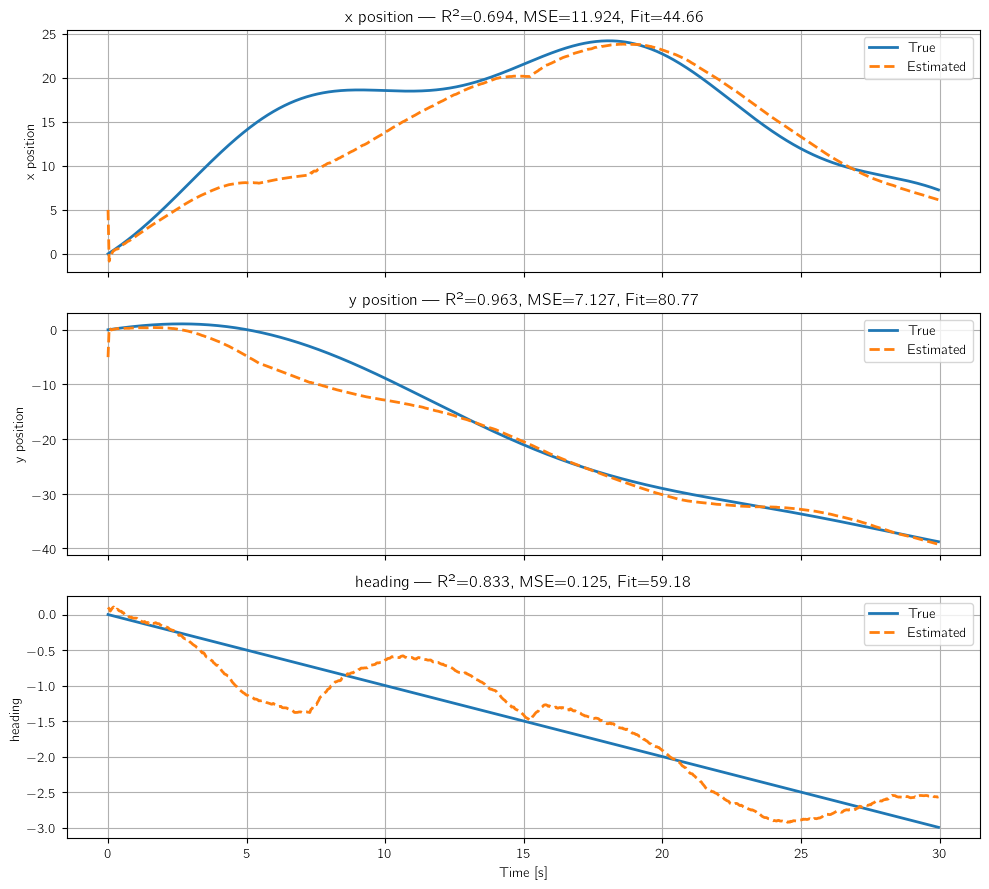

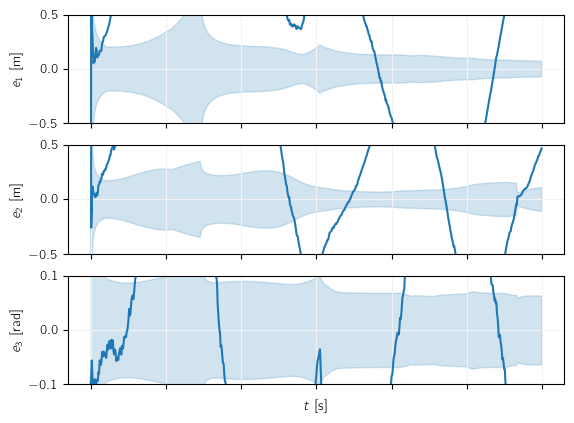

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


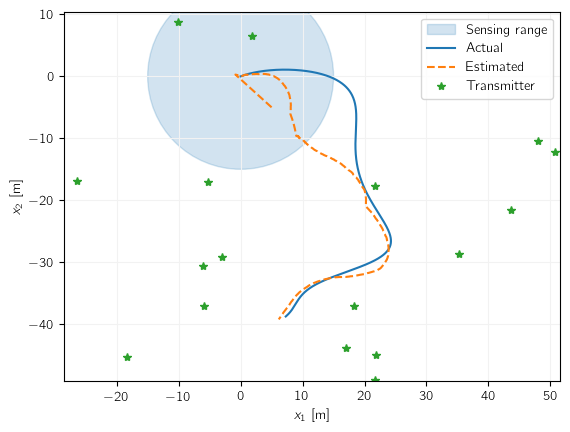

In [2]:


# %%
# SIMULATION SETUP (GOOD UKF) = Plane UKF, WITH DISTURBANCE

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import chi2
from scipy.linalg import block_diag
from numpy.linalg import inv
from integration2 import rk_four
from models2 import DiffDrive

# Set the simulation time [s] and the sample period [s]
SIM_TIME = 30.0
T = 0.04

# Create an array of time values [s]
t = np.arange(0.0, SIM_TIME, T)
N = np.size(t)

# %%
# VEHICLE SETUP

# Set the track length of the vehicle [m]
ELL = 1.0

# Create a vehicle object of type DiffDrive
vehicle = DiffDrive(ELL)

# %%
# BUILD A MAP OF FEATURES IN THE VEHICLE'S ENVIRONMENT

# Number of features
M = 150

# Map size [m]
D_MAP = 100

# Randomly place features in the map
f_map = np.zeros((2, M))
for i in range(0, M):
    f_map[:, i] = D_MAP * (2.0 * np.random.rand(2) - 1.0)

# %%
# SENSOR MODELS

# Uncertainty in wheel speeds [m/s]
SIGMA_SPEED = 0.1

# Max and min sensor ranges
R_MAX = 15
R_MIN = 1

# Set the range [m] and bearing [rad] uncertainty
SIGMA_RANGE = 0.3
SIGMA_BEARING = 15 * np.pi / 180

# Create a range and bearing sensor model
def RandB_sensor(x, f_map, R):

    # Define how many total features are available
    m = np.shape(f_map)[1]

    # Find the indices of features that are within range [r_min, r_max]
    a = np.array([])
    for i in range(0, m):
        r = np.sqrt((f_map[0, i] - x[0]) ** 2 + (f_map[1, i] - x[1]) ** 2)
        if np.all(
            [
                r < R_MAX,
                r > R_MIN,
            ]
        ):
            a = np.append(a, i)

    # Compute the range and bearing to all features within range
    if np.shape(a)[0] > 0:
        # Specify the size of the output
        m_k = np.shape(a)[0]
        y = np.zeros(2 * m_k)

        # Compute the range and bearing to all features (including sensor noise)
        for i in range(0, m_k):
            # Range measurement [m]
            y[2 * i] = (
                np.sqrt(
                    (f_map[0, int(a[i])] - x[0]) ** 2
                    + (f_map[1, int(a[i])] - x[1]) ** 2
                )
                + np.sqrt(R[0, 0]) * np.random.randn(1)[0]
            )
            # Bearing measurement [rad]
            y[2 * i + 1] = (
                np.unwrap(
                    np.array(
                        [
                            np.arctan2(
                                f_map[1, int(a[i])] - x[1], f_map[0, int(a[i])] - x[0]
                            )
                            - x[2]
                        ]
                    )
                )[0]
                - np.pi
                + np.sqrt(R[1, 1]) * np.random.randn(1)[0]
            )
    else:
        # No features were found within the sensing range
        y = np.array([])

    # Return the range and bearing to features in y with indices in a
    return y, a


# %%
# CREATE A UKF-BASED ESTIMATOR


def UKF(x, P, v_m, y_m, a, f_map, Q, R, kappa): #generating a gaussian distribution that is passed through the model based on the current state and uncertainty then take a weighted average of sigma points propagated throught the model

    # Set the augmented state and covariance
    xi = np.append(x, v_m)
    n_x = np.shape(x)[0] #since technically column vector need the [0] to get the correct shape/size as 1D vector
    n_xi = np.shape(xi)[0]
    P_xi = block_diag(P, Q) #augmented covaraince vector including the model process noise

    # Define a set of sigma points for for the a priori estimate
    xi_sig = np.zeros((n_xi, 2 * n_xi + 1)) #signma points are defined using equations written in the notebook. Points around the mean to represent gaussian distribution. Normally 2n+1 sigma points
    P_xi_sig = np.linalg.cholesky((n_xi + kappa) * P_xi) #The square root matrix satisfying A = AT and xTsum(x) >0 (positive semi definite)defined the covaraince sigma point used for calculating the sigma points from cholesky decomposition. Equations shown in the notebook. kappa is the tunning parameter and is nominally 3-nx. Gives directions in state space showing how uncertainity spreads around the mean
    xi_sig[:, 0] = xi #the first sigma point is the first state
    for i in range(0, n_xi): #sigma points are calculated here
        xi_sig[:, i + 1] = xi + P_xi_sig[:, i] #next sigma points is the current sigma point plus the cov sigma
        xi_sig[:, n_xi + i + 1] = xi - P_xi_sig[:, i] #points must be symmetric around the mean (sampling gaussian), plus spread, minus spread 

    # Propagate each sigma point through the vehicle's model => sampling the distribution of x through the model after creating the distribution with the sigma points
    #approximating the distribution as a gaussian, passing though the exact model(why its better, not the linear model) and the get approximate belief distribution
    xi_sig_hat = np.zeros((n_xi, 2 * n_xi + 1)) #this is where the PINN can fit it as it can learn the model from the non-linear dynamics.
    for i in range(0, 2 * n_xi + 1):
        xi_sig_hat[0:n_x, i] = rk_four( #rk4 integration is used to numerically solve the differential equation
            vehicle.f, xi_sig[0:n_x, i], xi_sig[n_x:n_xi, i], T
        )

    # Compute the mean and covariance from the transformed sigma points => resulting mean and covariance
    w_xi = 0.5 / (n_xi + kappa) * np.ones(2 * n_xi + 1) #weights associated witht he unscented transform. 1/2(n+k)
    w_xi[0] = 2 * kappa * w_xi[0]
    #recombine after prediction. With predicted state and how uncertain you are after the prediction
    xi = np.average(xi_sig_hat, axis=1, weights=w_xi) #weighted predicted mean
    P_xi = np.cov(xi_sig_hat, ddof=0, aweights=w_xi) #covariance is the variance of the predicted measurement where each measurement is assigned a weight. Covariance weight

    # Help to keep the covariance matrix symmetrical
    P_xi = (P_xi + np.transpose(P_xi)) / 2 #=> covaraince matrix must be symmetric meaning the matrix equals the transpose and this ensures that

    # Set the vehicle state estimates. Setting the new predicted state
    x_hat = xi[0:n_x]
    P_hat = P_xi[0:n_x, 0:n_x]

    # Find the number of observed features
    m_k = np.shape(a)[0]

    # Compute the a posteriori estimate if there are visible features
    if m_k > 0:

        # Compute a new set of sigma points using the latest x_hat and P_hat. New sigma points from the predicted state
        x_sig = np.zeros((n_x, 2 * n_x + 1)) #same process is done for the prediction step for measurement estimate
        P_sig = np.linalg.cholesky((n_x + kappa) * P_hat)
        x_sig[:, 0] = x_hat
        for i in range(0, n_x):
            x_sig[:, i + 1] = x_hat + P_sig[:, i]
            x_sig[:, n_x + i + 1] = x_hat - P_sig[:, i]

        # Find the expected measurement corresponding to each sigma point
        y_hat_sig = np.zeros((2 * m_k, 2 * n_x + 1))
        for j in range(0, 2 * n_x + 1):
            # Compute the expected measurements
            for i in range(0, m_k):
                y_hat_sig[2 * i, j] = np.sqrt(
                    (f_map[0, int(a[i])] - x_sig[0, j]) ** 2
                    + (f_map[1, int(a[i])] - x_sig[1, j]) ** 2
                )
                y_hat_sig[2 * i + 1, j] = (
                    np.unwrap(
                        [
                            np.arctan2(
                                f_map[1, int(a[i])] - x_sig[1, j],
                                f_map[0, int(a[i])] - x_sig[0, j],
                            )
                            - x_sig[2, j]
                        ]
                    )[0]
                    - np.pi
                )

        # Recombine the sigma points => same process as before
        w_x = 0.5 / (n_x + kappa) * np.ones(2 * n_x + 1)
        w_x[0] = 2 * kappa * w_x[0]
        y_hat = np.average(y_hat_sig, axis=1, weights=w_x)
        P_y = np.zeros((2 * m_k, 2 * m_k))
        P_xy = np.zeros((n_x, 2 * m_k))
        for i in range(0, 2 * n_x + 1): #compute the variance and cross covaraince
            y_diff = y_hat_sig[:, i] - y_hat
            x_diff = x_sig[:, i] - x_hat
            P_y = P_y + w_x[i] * (y_diff.reshape((2 * m_k, 1))) @ np.transpose(
                y_diff.reshape((2 * m_k, 1))
            )
            P_xy = P_xy + w_x[i] * (x_diff.reshape((n_x, 1))) @ np.transpose(
                y_diff.reshape((2 * m_k, 1))
            )
        P_y = P_y + np.kron(np.identity(m_k), R) #adding the measurment noise

        # Help to keep the covariance matrix symmetrical
        P_y = (P_y + np.transpose(P_y)) / 2

        # Update the estimate => this comes from the mathematics behind the generalized gaussian filter which is a way to compute the kalman filter gain
        K = P_xy @ inv(P_y)
        x_hat = x_hat + K @ (y_m - y_hat) #correcting the state estimate based on the kalman gain
        P_hat = P_hat - K @ P_y @ np.transpose(K) #correcting the covaraince

        # Help keep the covariance matrix symmetric
        P_hat = (P_hat + np.transpose(P_hat)) / 2

    return x_hat, P_hat


# %%
# SIMULATE THE SYSTEM

# Set the covariance matrices
Q = np.diag([SIGMA_SPEED**2, SIGMA_SPEED**2]) #simulate the variance in the state, Process noise
R = np.diag([SIGMA_RANGE**2, SIGMA_BEARING**2]) #simulating variance, measurement noise

# Initialize state, input, and estimator variables
x = np.zeros((3, N))
v_m = np.zeros((2, N))
x_hat_UKF = np.zeros((3, N))
P_hat_UKF = np.zeros((3, 3, N))

# Initialize the state
x_init = np.zeros(3)

# Set the initial guess of the estimator
x_guess = x_init + np.array([5.0, -5.0, 0.1]) #initial guess of the state
P_guess = np.diag(np.square([5.0, -5.0, 0.1])) #initial guess of the covariance

# Set the initial conditions
x[:, 0] = x_init
v_m[:, 0] = np.zeros(2)
x_hat_UKF[:, 0] = x_guess
P_hat_UKF[:, :, 0] = P_guess

KAPPA = 3 - np.shape(x)[0]

for i in range(1, N):

    # Compute some inputs (i.e., drive around)
    v = np.array([2.05, 1.95])


    # Run the vehicle motion model
    x[:, i] = rk_four(vehicle.f, x[:, i - 1], v, T) #column vector with each state. Simulated trajectory
    
    #ADDING DISTURBANCES TO MIMIC REAL WORLD (REMOVE TO SEE PERFORMANCE WITHOUT DISTURBANCES)
    x[0, i] += 0.05 * np.sin(0.5 * t[i])   # x drift
    x[1, i] += 0.03 * np.cos(0.3 * t[i])   # y drift
    #x[2, i] += 0.01 * np.random.randn()  
    #END OF DISTURBANCES SECTION 
    
    # Model the rate sensors => same here and gets appeneded to x in the augmented state
    v_m[0, i] = v[0] + np.sqrt(Q[0, 0]) * np.random.randn(1)[0]
    v_m[1, i] = v[1] + np.sqrt(Q[1, 1]) * np.random.randn(1)[0]

    # Run the measurement model
    y_m, a = RandB_sensor(x[:, i], f_map, R)

    # Run the UKF estimator
    x_hat_UKF[:, i], P_hat_UKF[:, :, i] = UKF(
        x_hat_UKF[:, i - 1], #previous state
        P_hat_UKF[:, :, i - 1],
        v_m[:, i - 1],
        y_m,
        a,
        f_map,
        Q,
        R,
        KAPPA,
    )

# %%
# PLOT THE SIMULATION OUTPUTS and BEST FIT 

def best_fit(y_hat, y, t, labels=None):
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)

    n_states, N = y.shape

    if labels is None:
        labels = [f"State {i}" for i in range(n_states)]

    metrics = {}

    fig, axes = plt.subplots(n_states, 1, figsize=(10, 3 * n_states), sharex=True)

    if n_states == 1:
        axes = [axes]

    for i in range(n_states):
        y_true = y[i, :]
        y_est = y_hat[i, :]

        # Errors
        err = y_true - y_est
        mse = np.mean(err**2)
        rmse = np.sqrt(mse)

        # R^2
        ss_res = np.sum(err**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Percent fit
        denom = np.linalg.norm(y_true - np.mean(y_true))
        fit_percent = 100 * (1 - np.linalg.norm(err) / denom) if denom > 0 else np.nan

        metrics[labels[i]] = {
            "R2": r2,
            "MSE": mse,
            "RMSE": rmse,
            "FitPercent": fit_percent,
        }

        # Plot
        axes[i].plot(t, y_true, label="True", linewidth=2)
        axes[i].plot(t, y_est, "--", label="Estimated", linewidth=2)
        axes[i].set_ylabel(labels[i])
        axes[i].grid(True)
        axes[i].legend()
        axes[i].set_title(
            f"{labels[i]} | R²={r2:.3f}, MSE={mse:.3f}, Fit={fit_percent:.2f}%"
        )

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()

    return metrics

metrics = best_fit(
    x_hat_UKF,
    x,
    t,
    labels=["x position", "y position", "heading"]
)

# Change some plot settings (optional)
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r"\usepackage{cmbright,amsmath,bm}")
plt.rc("savefig", format="pdf")
plt.rc("savefig", bbox="tight")

# Find the scaling factors for covariance bounds
ALPHA = 0.01
s1 = chi2.isf(ALPHA, 1)
s2 = chi2.isf(ALPHA, 2)

# Set some plot limits for better viewing
X_RANGE = 0.5
Y_RANGE = 0.5
THETA_RANGE = 0.1
PHI_RANGE = 0.1

# Plot the errors with covariance bounds
sigma = np.zeros((3, N))
fig1 = plt.figure(1)
ax1 = plt.subplot(311)
sigma[0, :] = np.sqrt(s1 * P_hat_UKF[0, 0, :])
plt.fill_between(t, -sigma[0, :], sigma[0, :], color="C0", alpha=0.2)
plt.plot(t, x[0, :] - x_hat_UKF[0, :], "C0")
plt.ylabel(r"$e_1$ [m]")
plt.setp(ax1, xticklabels=[])
ax1.set_ylim([-X_RANGE, X_RANGE])
plt.grid(color="0.95")
ax2 = plt.subplot(312)
sigma[1, :] = np.sqrt(s1 * P_hat_UKF[1, 1, :])
plt.fill_between(t, -sigma[1, :], sigma[1, :], color="C0", alpha=0.2)
plt.plot(t, x[1, :] - x_hat_UKF[1, :], "C0")
plt.ylabel(r"$e_2$ [m]")
plt.setp(ax2, xticklabels=[])
ax2.set_ylim([-Y_RANGE, Y_RANGE])
plt.grid(color="0.95")
ax3 = plt.subplot(313)
sigma[2, :] = np.sqrt(s1 * P_hat_UKF[2, 2, :])
plt.fill_between(t, -sigma[2, :], sigma[2, :], color="C0", alpha=0.2)
plt.plot(t, x[2, :] - x_hat_UKF[2, :], "C0")
plt.ylabel(r"$e_3$ [rad]")
plt.setp(ax3, xticklabels=[])
ax3.set_ylim([-THETA_RANGE, THETA_RANGE])
plt.xlabel(r"$t$ [s]")
plt.grid(color="0.95")

# Plot the actual versus estimated positions on the map
fig2, ax = plt.subplots()
circle = Circle(x[0:2, 0], radius=R_MAX, alpha=0.2, color="C0", label="Sensing range")
ax.add_artist(circle)
plt.plot(x[0, :], x[1, :], "C0", label="Actual")
plt.plot(x_hat_UKF[0, :], x_hat_UKF[1, :], "C1--", label="Estimated")
plt.plot(f_map[0, :], f_map[1, :], "C2*", label="Transmitter")
plt.axis("equal")
ax.set_xlim([np.min(x_hat_UKF[0, :]) - 10, np.max(x_hat_UKF[0, :]) + 10])
ax.set_ylim([np.min(x_hat_UKF[1, :]) - 10, np.max(x_hat_UKF[1, :]) + 10])
plt.xlabel(r"$x_1$ [m]")
plt.ylabel(r"$x_2$ [m]")
plt.grid(color="0.95")
plt.legend()

# Show the plot to the screen
plt.show()

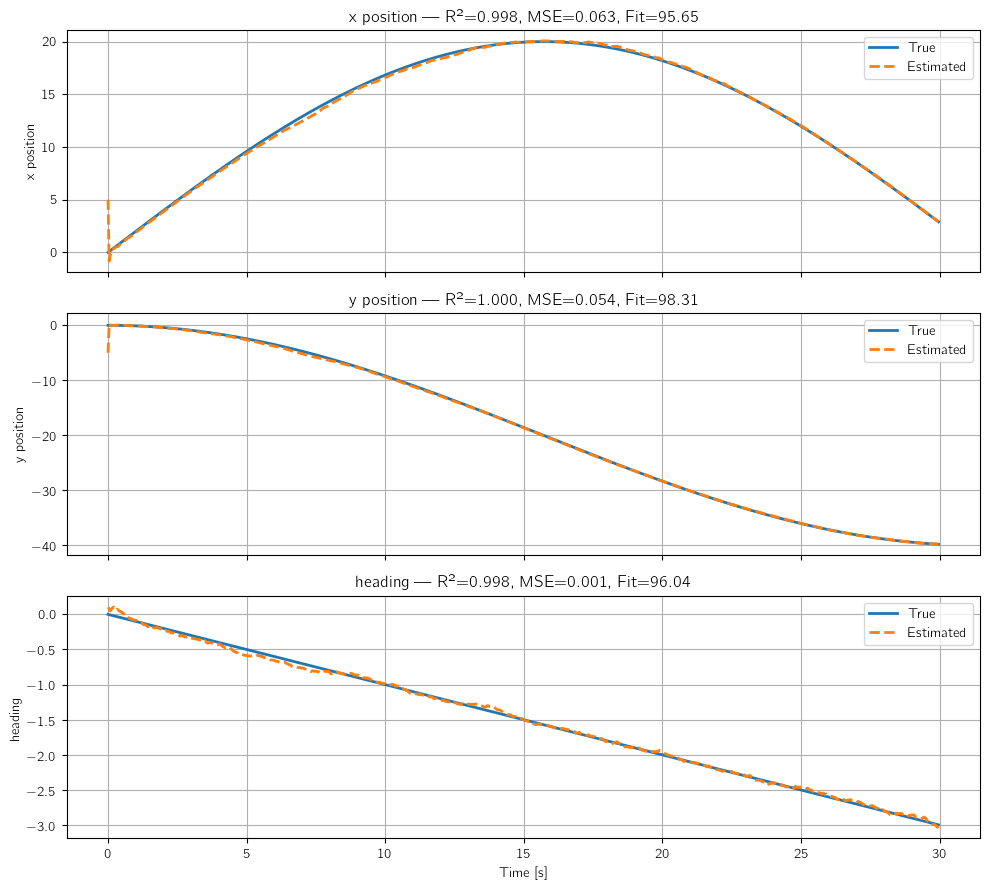

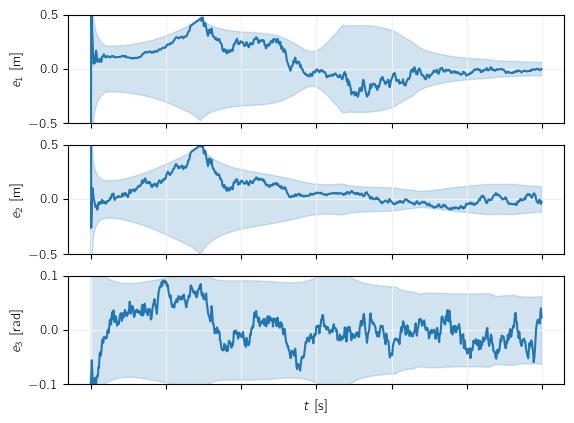

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


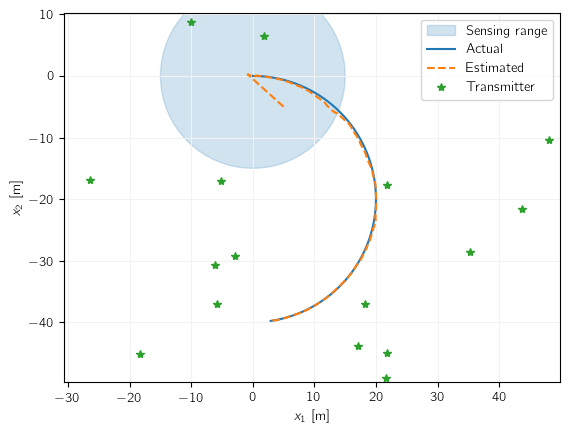

In [4]:
# %%
# SIMULATION SETUP (GOOD UKF) =Plane UKF, WITHOUT DISTURBANCE

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import chi2
from scipy.linalg import block_diag
from numpy.linalg import inv
from integration2 import rk_four
from models2 import DiffDrive

# Set the simulation time [s] and the sample period [s]
SIM_TIME = 30.0
T = 0.04

# Create an array of time values [s]
t = np.arange(0.0, SIM_TIME, T)
N = np.size(t)

# %%
# VEHICLE SETUP

# Set the track length of the vehicle [m]
ELL = 1.0

# Create a vehicle object of type DiffDrive
vehicle = DiffDrive(ELL)

# %%
# BUILD A MAP OF FEATURES IN THE VEHICLE'S ENVIRONMENT

# Number of features
M = 150

# Map size [m]
D_MAP = 100

# Randomly place features in the map
f_map = np.zeros((2, M))
for i in range(0, M):
    f_map[:, i] = D_MAP * (2.0 * np.random.rand(2) - 1.0)

# %%
# SENSOR MODELS

# Uncertainty in wheel speeds [m/s]
SIGMA_SPEED = 0.1

# Max and min sensor ranges
R_MAX = 15
R_MIN = 1

# Set the range [m] and bearing [rad] uncertainty
SIGMA_RANGE = 0.3
SIGMA_BEARING = 15 * np.pi / 180

# Create a range and bearing sensor model
def RandB_sensor(x, f_map, R):

    # Define how many total features are available
    m = np.shape(f_map)[1]

    # Find the indices of features that are within range [r_min, r_max]
    a = np.array([])
    for i in range(0, m):
        r = np.sqrt((f_map[0, i] - x[0]) ** 2 + (f_map[1, i] - x[1]) ** 2)
        if np.all(
            [
                r < R_MAX,
                r > R_MIN,
            ]
        ):
            a = np.append(a, i)

    # Compute the range and bearing to all features within range
    if np.shape(a)[0] > 0:
        # Specify the size of the output
        m_k = np.shape(a)[0]
        y = np.zeros(2 * m_k)

        # Compute the range and bearing to all features (including sensor noise)
        for i in range(0, m_k):
            # Range measurement [m]
            y[2 * i] = (
                np.sqrt(
                    (f_map[0, int(a[i])] - x[0]) ** 2
                    + (f_map[1, int(a[i])] - x[1]) ** 2
                )
                + np.sqrt(R[0, 0]) * np.random.randn(1)[0]
            )
            # Bearing measurement [rad]
            y[2 * i + 1] = (
                np.unwrap(
                    np.array(
                        [
                            np.arctan2(
                                f_map[1, int(a[i])] - x[1], f_map[0, int(a[i])] - x[0]
                            )
                            - x[2]
                        ]
                    )
                )[0]
                - np.pi
                + np.sqrt(R[1, 1]) * np.random.randn(1)[0]
            )
    else:
        # No features were found within the sensing range
        y = np.array([])

    # Return the range and bearing to features in y with indices in a
    return y, a


# %%
# CREATE A UKF-BASED ESTIMATOR


def UKF(x, P, v_m, y_m, a, f_map, Q, R, kappa): #generating a gaussian distribution that is passed through the model based on the current state and uncertainty then take a weighted average of sigma points propagated throught the model

    # Set the augmented state and covariance
    xi = np.append(x, v_m)
    n_x = np.shape(x)[0] #since technically column vector need the [0] to get the correct shape/size as 1D vector
    n_xi = np.shape(xi)[0]
    P_xi = block_diag(P, Q) #augmented covaraince vector including the model process noise

    # Define a set of sigma points for for the a priori estimate
    xi_sig = np.zeros((n_xi, 2 * n_xi + 1)) #signma points are defined using equations written in the notebook. Points around the mean to represent gaussian distribution. Normally 2n+1 sigma points
    P_xi_sig = np.linalg.cholesky((n_xi + kappa) * P_xi) #The square root matrix satisfying A = AT and xTsum(x) >0 (positive semi definite)defined the covaraince sigma point used for calculating the sigma points from cholesky decomposition. Equations shown in the notebook. kappa is the tunning parameter and is nominally 3-nx. Gives directions in state space showing how uncertainity spreads around the mean
    xi_sig[:, 0] = xi #the first sigma point is the first state
    for i in range(0, n_xi): #sigma points are calculated here
        xi_sig[:, i + 1] = xi + P_xi_sig[:, i] #next sigma points is the current sigma point plus the cov sigma
        xi_sig[:, n_xi + i + 1] = xi - P_xi_sig[:, i] #points must be symmetric around the mean (sampling gaussian), plus spread, minus spread 

    # Propagate each sigma point through the vehicle's model => sampling the distribution of x through the model after creating the distribution with the sigma points
    #approximating the distribution as a gaussian, passing though the exact model(why its better, not the linear model) and the get approximate belief distribution
    xi_sig_hat = np.zeros((n_xi, 2 * n_xi + 1)) #this is where the PINN can fit it as it can learn the model from the non-linear dynamics.
    for i in range(0, 2 * n_xi + 1):
        xi_sig_hat[0:n_x, i] = rk_four( #rk4 integration is used to numerically solve the differential equation
            vehicle.f, xi_sig[0:n_x, i], xi_sig[n_x:n_xi, i], T
        )

    # Compute the mean and covariance from the transformed sigma points => resulting mean and covariance
    w_xi = 0.5 / (n_xi + kappa) * np.ones(2 * n_xi + 1) #weights associated witht he unscented transform. 1/2(n+k)
    w_xi[0] = 2 * kappa * w_xi[0]
    #recombine after prediction. With predicted state and how uncertain you are after the prediction
    xi = np.average(xi_sig_hat, axis=1, weights=w_xi) #weighted predicted mean
    P_xi = np.cov(xi_sig_hat, ddof=0, aweights=w_xi) #covariance is the variance of the predicted measurement where each measurement is assigned a weight. Covariance weight

    # Help to keep the covariance matrix symmetrical
    P_xi = (P_xi + np.transpose(P_xi)) / 2 #=> covaraince matrix must be symmetric meaning the matrix equals the transpose and this ensures that

    # Set the vehicle state estimates. Setting the new predicted state
    x_hat = xi[0:n_x]
    P_hat = P_xi[0:n_x, 0:n_x]

    # Find the number of observed features
    m_k = np.shape(a)[0]

    # Compute the a posteriori estimate if there are visible features
    if m_k > 0:

        # Compute a new set of sigma points using the latest x_hat and P_hat. New sigma points from the predicted state
        x_sig = np.zeros((n_x, 2 * n_x + 1)) #same process is done for the prediction step for measurement estimate
        P_sig = np.linalg.cholesky((n_x + kappa) * P_hat)
        x_sig[:, 0] = x_hat
        for i in range(0, n_x):
            x_sig[:, i + 1] = x_hat + P_sig[:, i]
            x_sig[:, n_x + i + 1] = x_hat - P_sig[:, i]

        # Find the expected measurement corresponding to each sigma point
        y_hat_sig = np.zeros((2 * m_k, 2 * n_x + 1))
        for j in range(0, 2 * n_x + 1):
            # Compute the expected measurements
            for i in range(0, m_k):
                y_hat_sig[2 * i, j] = np.sqrt(
                    (f_map[0, int(a[i])] - x_sig[0, j]) ** 2
                    + (f_map[1, int(a[i])] - x_sig[1, j]) ** 2
                )
                y_hat_sig[2 * i + 1, j] = (
                    np.unwrap(
                        [
                            np.arctan2(
                                f_map[1, int(a[i])] - x_sig[1, j],
                                f_map[0, int(a[i])] - x_sig[0, j],
                            )
                            - x_sig[2, j]
                        ]
                    )[0]
                    - np.pi
                )

        # Recombine the sigma points => same process as before
        w_x = 0.5 / (n_x + kappa) * np.ones(2 * n_x + 1)
        w_x[0] = 2 * kappa * w_x[0]
        y_hat = np.average(y_hat_sig, axis=1, weights=w_x)
        P_y = np.zeros((2 * m_k, 2 * m_k))
        P_xy = np.zeros((n_x, 2 * m_k))
        for i in range(0, 2 * n_x + 1): #compute the variance and cross covaraince
            y_diff = y_hat_sig[:, i] - y_hat
            x_diff = x_sig[:, i] - x_hat
            P_y = P_y + w_x[i] * (y_diff.reshape((2 * m_k, 1))) @ np.transpose(
                y_diff.reshape((2 * m_k, 1))
            )
            P_xy = P_xy + w_x[i] * (x_diff.reshape((n_x, 1))) @ np.transpose(
                y_diff.reshape((2 * m_k, 1))
            )
        P_y = P_y + np.kron(np.identity(m_k), R) #adding the measurment noise

        # Help to keep the covariance matrix symmetrical
        P_y = (P_y + np.transpose(P_y)) / 2

        # Update the estimate => this comes from the mathematics behind the generalized gaussian filter which is a way to compute the kalman filter gain
        K = P_xy @ inv(P_y)
        x_hat = x_hat + K @ (y_m - y_hat) #correcting the state estimate based on the kalman gain
        P_hat = P_hat - K @ P_y @ np.transpose(K) #correcting the covaraince

        # Help keep the covariance matrix symmetric
        P_hat = (P_hat + np.transpose(P_hat)) / 2

    return x_hat, P_hat


# %%
# SIMULATE THE SYSTEM

# Set the covariance matrices
Q = np.diag([SIGMA_SPEED**2, SIGMA_SPEED**2]) #simulate the variance in the state, Process noise
R = np.diag([SIGMA_RANGE**2, SIGMA_BEARING**2]) #simulating variance, measurement noise

# Initialize state, input, and estimator variables
x = np.zeros((3, N))
v_m = np.zeros((2, N))
x_hat_UKF = np.zeros((3, N))
P_hat_UKF = np.zeros((3, 3, N))

# Initialize the state
x_init = np.zeros(3)

# Set the initial guess of the estimator
x_guess = x_init + np.array([5.0, -5.0, 0.1]) #initial guess of the state
P_guess = np.diag(np.square([5.0, -5.0, 0.1])) #initial guess of the covariance

# Set the initial conditions
x[:, 0] = x_init
v_m[:, 0] = np.zeros(2)
x_hat_UKF[:, 0] = x_guess
P_hat_UKF[:, :, 0] = P_guess

KAPPA = 3 - np.shape(x)[0]

for i in range(1, N):

    # Compute some inputs (i.e., drive around)
    v = np.array([2.05, 1.95])


    # Run the vehicle motion model
    x[:, i] = rk_four(vehicle.f, x[:, i - 1], v, T) #column vector with each state. Simulated trajectory
    
    #ADDING DISTURBANCES TO MIMIC REAL WORLD (REMOVE TO SEE PERFORMANCE WITHOUT DISTURBANCES)
    #x[0, i] += 0.05 * np.sin(0.5 * t[i])   # x drift
    #x[1, i] += 0.03 * np.cos(0.3 * t[i])   # y drift
    #x[2, i] += 0.01 * np.random.randn()  
    #END OF DISTURBANCES SECTION 
    
    # Model the rate sensors => same here and gets appeneded to x in the augmented state
    v_m[0, i] = v[0] + np.sqrt(Q[0, 0]) * np.random.randn(1)[0]
    v_m[1, i] = v[1] + np.sqrt(Q[1, 1]) * np.random.randn(1)[0]

    # Run the measurement model
    y_m, a = RandB_sensor(x[:, i], f_map, R)

    # Run the UKF estimator
    x_hat_UKF[:, i], P_hat_UKF[:, :, i] = UKF(
        x_hat_UKF[:, i - 1], #previous state
        P_hat_UKF[:, :, i - 1],
        v_m[:, i - 1],
        y_m,
        a,
        f_map,
        Q,
        R,
        KAPPA,
    )

# %%
# PLOT THE SIMULATION OUTPUTS and BEST FIT 

def best_fit(y_hat, y, t, labels=None):
    y = np.asarray(y)
    y_hat = np.asarray(y_hat)

    n_states, N = y.shape

    if labels is None:
        labels = [f"State {i}" for i in range(n_states)]

    metrics = {}

    fig, axes = plt.subplots(n_states, 1, figsize=(10, 3 * n_states), sharex=True)

    if n_states == 1:
        axes = [axes]

    for i in range(n_states):
        y_true = y[i, :]
        y_est = y_hat[i, :]

        # Errors
        err = y_true - y_est
        mse = np.mean(err**2)
        rmse = np.sqrt(mse)

        # R^2
        ss_res = np.sum(err**2)
        ss_tot = np.sum((y_true - np.mean(y_true))**2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan

        # Percent fit
        denom = np.linalg.norm(y_true - np.mean(y_true))
        fit_percent = 100 * (1 - np.linalg.norm(err) / denom) if denom > 0 else np.nan

        metrics[labels[i]] = {
            "R2": r2,
            "MSE": mse,
            "RMSE": rmse,
            "FitPercent": fit_percent,
        }

        # Plot
        axes[i].plot(t, y_true, label="True", linewidth=2)
        axes[i].plot(t, y_est, "--", label="Estimated", linewidth=2)
        axes[i].set_ylabel(labels[i])
        axes[i].grid(True)
        axes[i].legend()
        axes[i].set_title(
            f"{labels[i]} | R²={r2:.3f}, MSE={mse:.3f}, Fit={fit_percent:.2f}%"
        )

    axes[-1].set_xlabel("Time [s]")
    plt.tight_layout()
    plt.show()

    return metrics

metrics = best_fit(
    x_hat_UKF,
    x,
    t,
    labels=["x position", "y position", "heading"]
)

# Change some plot settings (optional)
plt.rc("text", usetex=True)
plt.rc("text.latex", preamble=r"\usepackage{cmbright,amsmath,bm}")
plt.rc("savefig", format="pdf")
plt.rc("savefig", bbox="tight")

# Find the scaling factors for covariance bounds
ALPHA = 0.01
s1 = chi2.isf(ALPHA, 1)
s2 = chi2.isf(ALPHA, 2)

# Set some plot limits for better viewing
X_RANGE = 0.5
Y_RANGE = 0.5
THETA_RANGE = 0.1
PHI_RANGE = 0.1

# Plot the errors with covariance bounds
sigma = np.zeros((3, N))
fig1 = plt.figure(1)
ax1 = plt.subplot(311)
sigma[0, :] = np.sqrt(s1 * P_hat_UKF[0, 0, :])
plt.fill_between(t, -sigma[0, :], sigma[0, :], color="C0", alpha=0.2)
plt.plot(t, x[0, :] - x_hat_UKF[0, :], "C0")
plt.ylabel(r"$e_1$ [m]")
plt.setp(ax1, xticklabels=[])
ax1.set_ylim([-X_RANGE, X_RANGE])
plt.grid(color="0.95")
ax2 = plt.subplot(312)
sigma[1, :] = np.sqrt(s1 * P_hat_UKF[1, 1, :])
plt.fill_between(t, -sigma[1, :], sigma[1, :], color="C0", alpha=0.2)
plt.plot(t, x[1, :] - x_hat_UKF[1, :], "C0")
plt.ylabel(r"$e_2$ [m]")
plt.setp(ax2, xticklabels=[])
ax2.set_ylim([-Y_RANGE, Y_RANGE])
plt.grid(color="0.95")
ax3 = plt.subplot(313)
sigma[2, :] = np.sqrt(s1 * P_hat_UKF[2, 2, :])
plt.fill_between(t, -sigma[2, :], sigma[2, :], color="C0", alpha=0.2)
plt.plot(t, x[2, :] - x_hat_UKF[2, :], "C0")
plt.ylabel(r"$e_3$ [rad]")
plt.setp(ax3, xticklabels=[])
ax3.set_ylim([-THETA_RANGE, THETA_RANGE])
plt.xlabel(r"$t$ [s]")
plt.grid(color="0.95")

# Plot the actual versus estimated positions on the map
fig2, ax = plt.subplots()
circle = Circle(x[0:2, 0], radius=R_MAX, alpha=0.2, color="C0", label="Sensing range")
ax.add_artist(circle)
plt.plot(x[0, :], x[1, :], "C0", label="Actual")
plt.plot(x_hat_UKF[0, :], x_hat_UKF[1, :], "C1--", label="Estimated")
plt.plot(f_map[0, :], f_map[1, :], "C2*", label="Transmitter")
plt.axis("equal")
ax.set_xlim([np.min(x_hat_UKF[0, :]) - 10, np.max(x_hat_UKF[0, :]) + 10])
ax.set_ylim([np.min(x_hat_UKF[1, :]) - 10, np.max(x_hat_UKF[1, :]) + 10])
plt.xlabel(r"$x_1$ [m]")
plt.ylabel(r"$x_2$ [m]")
plt.grid(color="0.95")
plt.legend()

# Show the plot to the screen
plt.show()

# Unscented Kalman Filter (UKF): Algorithm and Main Equations

## 1. Define Initial State and Covariance

the initial state

$$
\mathbf{x} \in \mathbb{R}^{3xN},
$$

and the initial input

$$
\mathbf{v} \in \mathbb{R}^{2xN},
$$

then the augmented state is

$$
\boldsymbol{\xi} = \begin{bmatrix} \mathbf{x} \\ \mathbf{v} \end{bmatrix}
\in \mathbb{R}^{n_\xi x N},
\qquad n_\xi = n_x + n_v.
$$

The augmented covariance is

$$
\mathbf{P}_{\xi} = \begin{bmatrix}
\mathbf{P} & \mathbf{0} \\
\mathbf{0} & \mathbf{Q}
\end{bmatrix},
$$

where:

- $\mathbf{P}$ is the current state covariance,
- $\mathbf{Q}$ is the process noise covariance.

## 2. Sigma Points

The UKF represents the Gaussian distribution using **sigma points**.

Given the mean $\boldsymbol{\xi}$ and covariance $\mathbf{P}_{\xi}$, define

$$
\mathbf{S} = \operatorname{chol}\big((n_\xi + \kappa)\mathbf{P}_{\xi}\big),
$$

where $\operatorname{chol}(\cdot)$ is the Cholesky decomposition used to determine the correct spread of points and $\kappa$ is a tuning parameter.

The sigma points are then. Spread around both the left and right side

$$
\boldsymbol{\xi}^{(0)} = \boldsymbol{\xi},
$$

$$
\boldsymbol{\xi}^{(i)} = \boldsymbol{\xi} + \mathbf{S}_{:,i}, \qquad i=1,\dots,n_\xi,
$$

$$
\boldsymbol{\xi}^{(n_\xi+i)} = \boldsymbol{\xi} - \mathbf{S}_{:,i}, \qquad i=1,\dots,n_\xi.
$$

The total amount of sigma points is typically the following

$$
2n_\xi + 1
$$

The typical value of the tuning parameter $\kappa$ is the following

$$
3 - n_x
$$



## 3. Sigma Point Weights

The unscented transform has associated weights which equations are listed bellow

$$
w^{(0)} = \frac{\kappa}{n_\xi + \kappa},
$$

$$
w^{(i)} = \frac{1}{2(n_\xi + \kappa)}, \qquad i=1,\dots,2n_\xi.
$$

These weights satisfy

$$
\sum_{i=0}^{2n_\xi} w^{(i)} = 1.
$$


# 11. Algorithm Summary

The UKF procedure in the function can be summarized as follows:

1. Form the augmented state and covariance using the state and process noise.
2. Generate sigma points from the augmented Gaussian distribution.
3. Propagate each sigma point through the nonlinear motion model.
4. Recombine the propagated sigma points to obtain the predicted state mean and covariance.
5. Generate sigma points again from the predicted state distribution.
6. Pass those sigma points through the nonlinear measurement model.
7. Compute the predicted measurement mean, measurement covariance, and cross-covariance.
8. Compute the Kalman gain.
9. Correct the predicted state using the measurement residual.
10. Update the covariance to obtain the final uncertainty matrix.